# Almeria Dataset - DAG Cloud Detection Pipeline

**Kaynak**: Fabel et al. (2022), *All-Sky Imager Cloud Segmentation Dataset Almeria*
DOI: [10.5281/zenodo.16647156](https://doi.org/10.5281/zenodo.16647156)

| Ozellik | Deger |
|---------|-------|
| Toplam goruntu | 818 (770 egitim + 48 test) |
| Format | JPEG 512x512 px |
| Etiket turu | 4 sinif segmentasyon maskesi |
| Kamera | Fisheye all-sky |
| Konum | Almeria, Ispanya |

**Siniflar:**
- 0: Maske disi
- 1: Bulutsuz gokyuzu
- 2: Alcak katman bulutlar
- 3: Orta katman bulutlar
- 4: Yuksek katman bulutlar

## 1. Kutuphaneler

In [1]:
import sys
sys.path.append('..')

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
from skimage.exposure import rescale_intensity
import pandas as pd
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')


from dag_cld import env, teacher

logger  = env.Logger(blabla=False)
svm_clf = teacher.SVM(logger)
knn_clf = teacher.KNN(logger)
lr_clf  = teacher.LR(logger)
nb_clf  = teacher.NB(logger)

print('Kutuphaneler yuklendi!')

Kutuphaneler yuklendi!


## 2. Veri Yollari

In [2]:
ALMERIA_DIR = '../almeria_data/kontas_2017'
IMAGES_DIR  = os.path.join(ALMERIA_DIR, 'images')
MASKS_DIR   = os.path.join(ALMERIA_DIR, 'seg_masks')

img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith('.jpg')])

print(f'Goruntu sayisi : {len(img_files)}')
test_img = np.array(Image.open(os.path.join(IMAGES_DIR, img_files[0])).convert('RGB'))
print(f'Goruntu boyutu: {test_img.shape}')

Goruntu sayisi : 770
Goruntu boyutu: (512, 512, 3)


## 3. Maskeden Etiket Cikar

In [3]:
def get_label(fname, cloud_threshold=0.15):
    """Segmentasyon maskesinden ikili etiket: 0=bulutlu, 1=acik"""
    mask_path = os.path.join(MASKS_DIR, fname.replace('.jpg', '.png'))
    if not os.path.exists(mask_path):
        return None
    seg   = np.array(Image.open(mask_path))
    valid = seg[seg > 0]
    if len(valid) == 0:
        return None
    cloud_ratio = np.sum(valid > 1) / len(valid)
    return 0 if cloud_ratio > cloud_threshold else 1

labels    = [(f, get_label(f)) for f in img_files]
labels    = [(f, l) for f, l in labels if l is not None]
n_clear   = sum(1 for _, l in labels if l == 1)
n_cloudy  = sum(1 for _, l in labels if l == 0)

print(f'Toplam gecerli: {len(labels)} goruntu')
print(f'Acik    : {n_clear}  ({n_clear/len(labels)*100:.1f}%)')
print(f'Bulutlu : {n_cloudy} ({n_cloudy/len(labels)*100:.1f}%)')

Toplam gecerli: 770 goruntu
Acik    : 246  (31.9%)
Bulutlu : 524 (68.1%)


## 4. Ornek Goruntuleri Goster

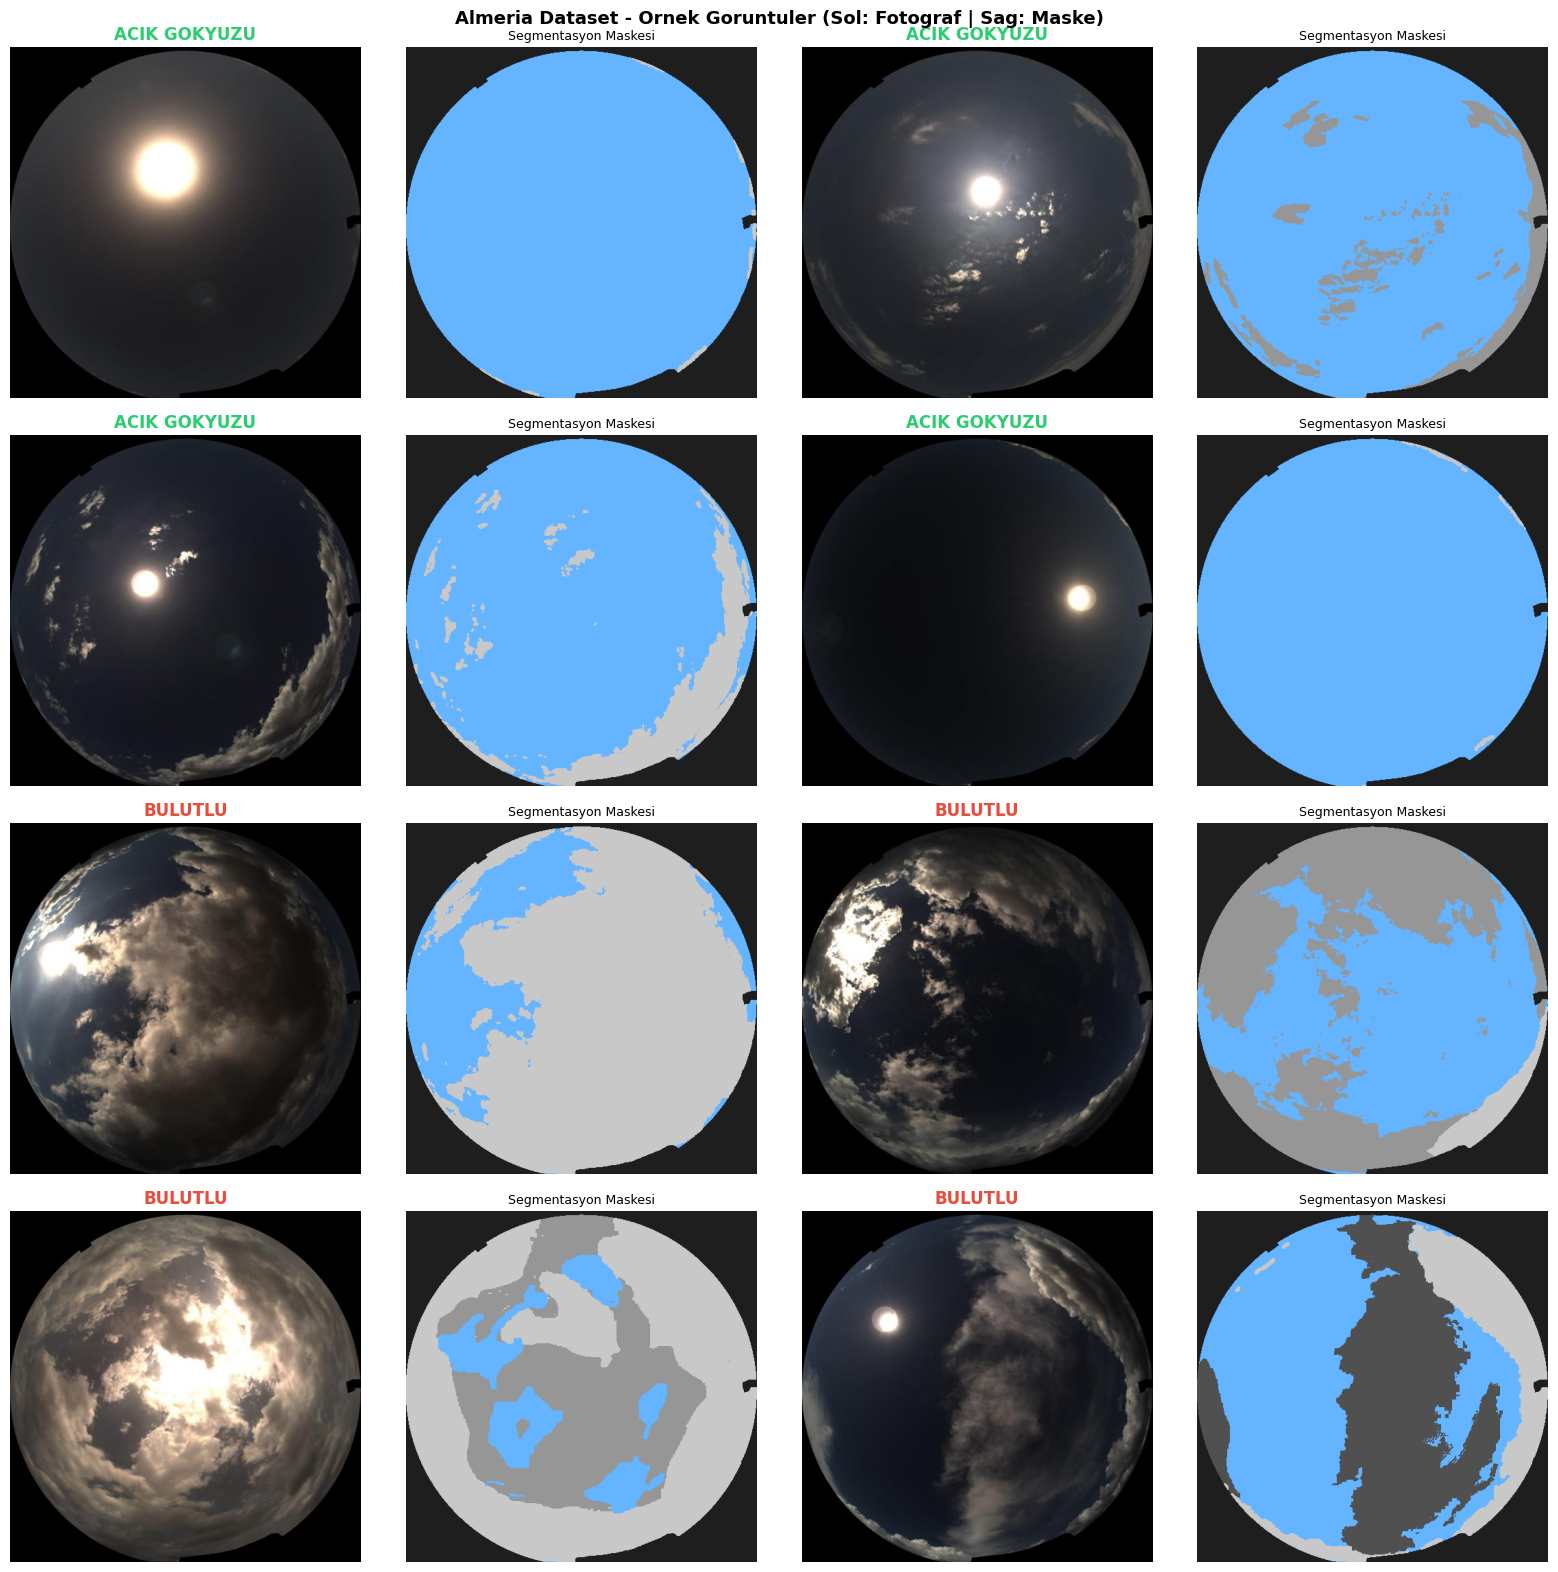

Kaydedildi: ../outputs/almeria_ornekler.png


In [4]:
CLASS_COLORS = {0:(30,30,30), 1:(100,180,255), 2:(200,200,200), 3:(150,150,150), 4:(80,80,80)}

def mask_to_rgb(seg):
    rgb = np.zeros((*seg.shape, 3), dtype=np.uint8)
    for cls, color in CLASS_COLORS.items():
        rgb[seg == cls] = color
    return rgb

clear_samples  = [f for f, l in labels if l == 1][:4]
cloudy_samples = [f for f, l in labels if l == 0][:4]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Almeria Dataset - Ornek Goruntuler (Sol: Fotograf | Sag: Maske)', fontsize=13, fontweight='bold')

for i, (fname, color, title) in enumerate([
    *[(f, '#2ecc71', 'ACIK GOKYUZU') for f in clear_samples],
    *[(f, '#e74c3c', 'BULUTLU') for f in cloudy_samples]
]):
    row = i // 2
    col_img  = (i % 2) * 2
    col_mask = col_img + 1
    img = np.array(Image.open(os.path.join(IMAGES_DIR, fname)))
    axes[row][col_img].imshow(img)
    axes[row][col_img].set_title(title, color=color, fontweight='bold')
    axes[row][col_img].axis('off')
    seg = np.array(Image.open(os.path.join(MASKS_DIR, fname.replace('.jpg','.png'))))
    axes[row][col_mask].imshow(mask_to_rgb(seg))
    axes[row][col_mask].set_title('Segmentasyon Maskesi', fontsize=9)
    axes[row][col_mask].axis('off')

plt.tight_layout()
plt.savefig('../outputs/almeria_ornekler.png', dpi=100, bbox_inches='tight')
plt.show()
print('Kaydedildi: ../outputs/almeria_ornekler.png')

## 5. HOG Ozellik Cikarma

In [5]:
def extract_hog(img_path, target_size=(128, 128)):
    img   = np.array(Image.open(img_path).convert('RGB'))
    gray  = rgb2gray(img)
    small = resize(gray, target_size, anti_aliasing=True)
    vec   = hog(small, orientations=8, pixels_per_cell=(16, 16),
               cells_per_block=(1, 1), visualize=False, channel_axis=None)
    return vec

test_vec = extract_hog(os.path.join(IMAGES_DIR, img_files[0]))
print(f'HOG vektor boyutu: {test_vec.shape[0]} ozellik')

HOG vektor boyutu: 512 ozellik


## 6. Tum Dataset'i Isle (770 Goruntu)

In [6]:
X_all  = []
y_all  = []
errors = 0

print(f'{len(labels)} goruntu isleniyor...')

for fname, label in tqdm(labels):
    try:
        vec = extract_hog(os.path.join(IMAGES_DIR, fname))
        X_all.append(vec)
        y_all.append(label)
    except Exception as e:
        errors += 1

X = np.array(X_all)
y = np.array(y_all)

print(f'Tamamlandi! ({errors} hata)')
print(f'X boyutu: {X.shape}')
print(f'Acik: {(y==1).sum()} | Bulutlu: {(y==0).sum()}')

770 goruntu isleniyor...


  0%|          | 0/770 [00:00<?, ?it/s]

Tamamlandi! (0 hata)
X boyutu: (770, 512)
Acik: 246 | Bulutlu: 524


## 7. ML Modelleri Egit

In [7]:
from sklearn.metrics import accuracy_score, f1_score

combined    = svm_clf.class_combiner(svm_clf.class_adder(X[y==1], 1), svm_clf.class_adder(X[y==0], 0))
combined    = svm_clf.shuffle(combined)
train, test = svm_clf.tts(combined, test_size=0.20)

X_train, y_train = train[:, :-1], train[:, -1]
X_test,  y_test  = test[:, :-1],  test[:, -1]

print(f'Egitim: {len(X_train)} | Test: {len(X_test)}')
print('=' * 50)

results = {}
models  = [
    ('SVM', svm_clf, lambda: svm_clf.classifier(X_train, y_train)),
    ('KNN', knn_clf, lambda: knn_clf.classifier(X_train, y_train, n_neighbors=5)),
    ('LR',  lr_clf,  lambda: lr_clf.classifier(X_train, y_train)),
    ('NB',  nb_clf,  lambda: nb_clf.classifier(X_train, y_train, tp='GAUSSIAN')),
]

for name, clf_obj, fit_fn in models:
    try:
        clf    = fit_fn()
        y_pred = clf_obj.predict(clf, X_test)
        acc    = accuracy_score(y_test, y_pred)
        f1     = f1_score(y_test, y_pred, average='weighted')
        results[name] = {'Accuracy': acc, 'F1': f1}
        print(f'{name:3s} -> Accuracy: {acc:.4f}  |  F1: {f1:.4f}')
    except Exception as e:
        print(f'{name}: HATA - {e}')

best = max(results, key=lambda k: results[k]['Accuracy'])
print(f'\nEn iyi model: {best} ({results[best]["Accuracy"]:.4f})')

Egitim: 616 | Test: 154
SVM -> Accuracy: 0.8701  |  F1: 0.8695
KNN -> Accuracy: 0.8896  |  F1: 0.8894
LR  -> Accuracy: 0.9091  |  F1: 0.9087
NB  -> Accuracy: 0.7727  |  F1: 0.7776

En iyi model: LR (0.9091)


## 8. Grafik

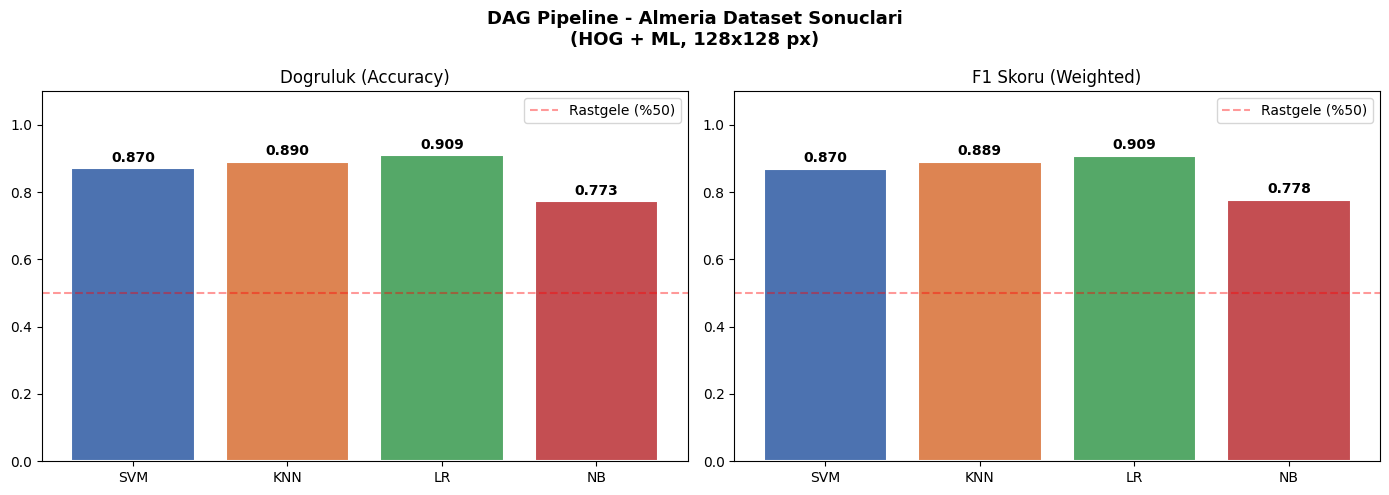

Kaydedildi: ../outputs/almeria_sonuclar.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DAG Pipeline - Almeria Dataset Sonuclari\n(HOG + ML, 128x128 px)', fontsize=13, fontweight='bold')

names  = list(results.keys())
accs   = [results[n]['Accuracy'] for n in names]
f1s    = [results[n]['F1']       for n in names]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars = axes[0].bar(names, accs, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Dogruluk (Accuracy)')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='red', ls='--', alpha=0.4, label='Rastgele (%50)')
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center', fontweight='bold')
axes[0].legend()

bars2 = axes[1].bar(names, f1s, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('F1 Skoru (Weighted)')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.5, color='red', ls='--', alpha=0.4, label='Rastgele (%50)')
for bar, val in zip(bars2, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/almeria_sonuclar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: ../outputs/almeria_sonuclar.png')

## 9. HOG Gorsellestirmesi

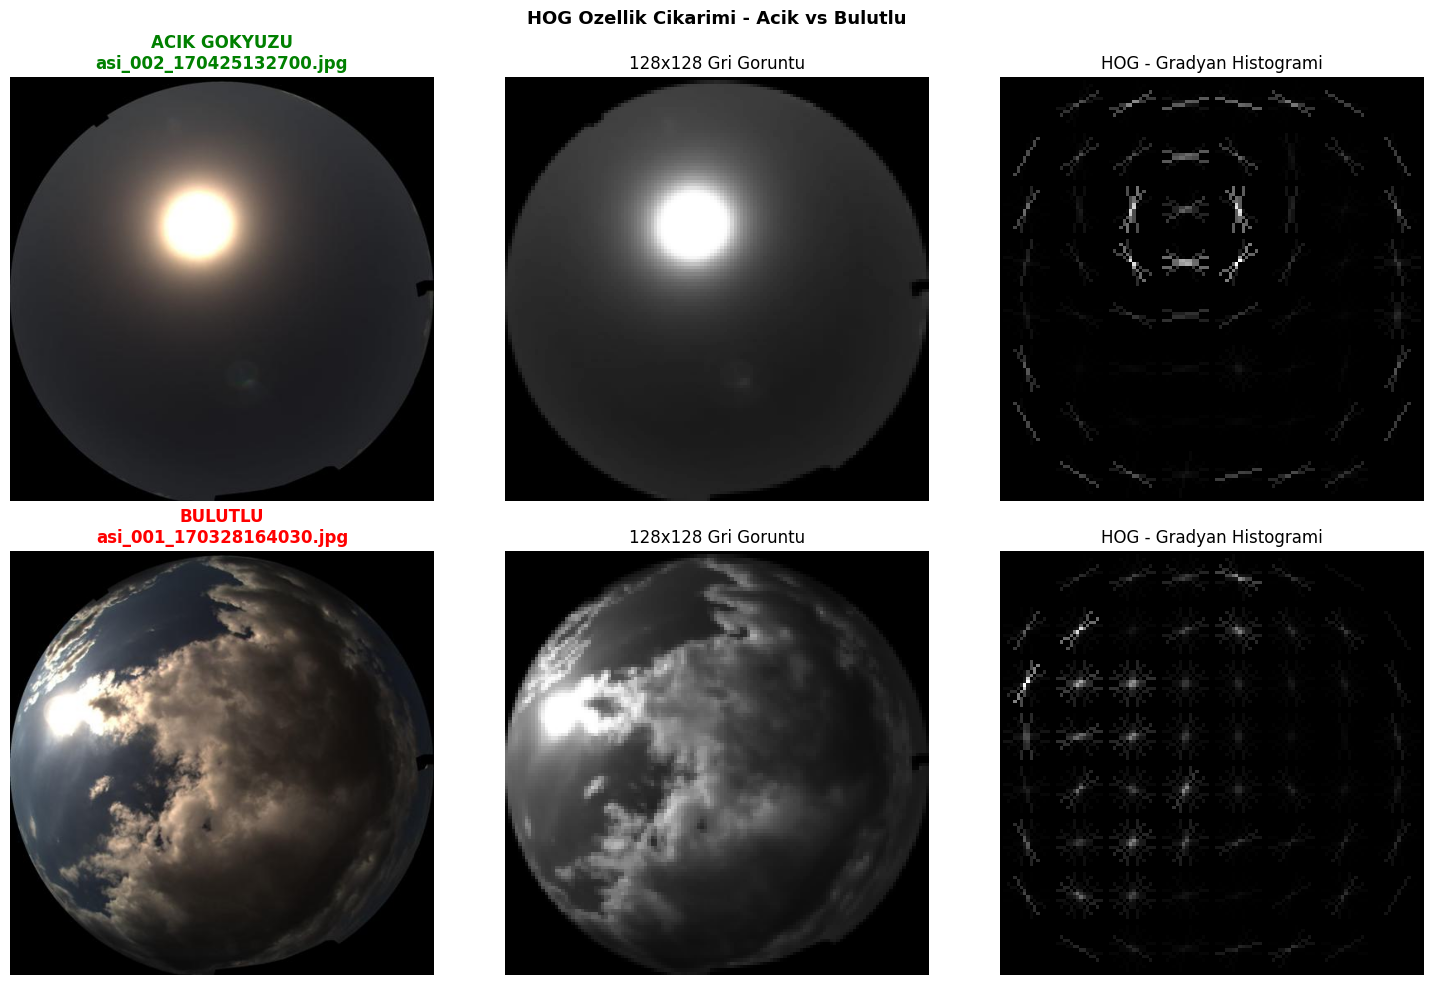

Kaydedildi: ../outputs/almeria_hog.png


In [9]:
clear_file  = next(f for f, l in labels if l == 1)
cloudy_file = next(f for f, l in labels if l == 0)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('HOG Ozellik Cikarimi - Acik vs Bulutlu', fontsize=13, fontweight='bold')

for row_i, (fname, title, color) in enumerate([
    (clear_file,  'ACIK GOKYUZU', 'green'),
    (cloudy_file, 'BULUTLU',      'red')
]):
    img   = np.array(Image.open(os.path.join(IMAGES_DIR, fname)).convert('RGB'))
    gray  = rgb2gray(img)
    small = resize(gray, (128, 128), anti_aliasing=True)
    fd, hog_img = hog(small, orientations=8, pixels_per_cell=(16,16),
                      cells_per_block=(1,1), visualize=True, channel_axis=None)
    axes[row_i][0].imshow(img)
    axes[row_i][0].set_title(f'{title}\n{fname[:35]}', color=color, fontweight='bold')
    axes[row_i][0].axis('off')
    axes[row_i][1].imshow(small, cmap='gray')
    axes[row_i][1].set_title('128x128 Gri Goruntu')
    axes[row_i][1].axis('off')
    axes[row_i][2].imshow(rescale_intensity(hog_img, in_range=(0,10)), cmap='gray')
    axes[row_i][2].set_title('HOG - Gradyan Histogrami')
    axes[row_i][2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/almeria_hog.png', dpi=120, bbox_inches='tight')
plt.show()
print('Kaydedildi: ../outputs/almeria_hog.png')

# İSTEK doğrultusunda seçilen resim ve model eğitimi

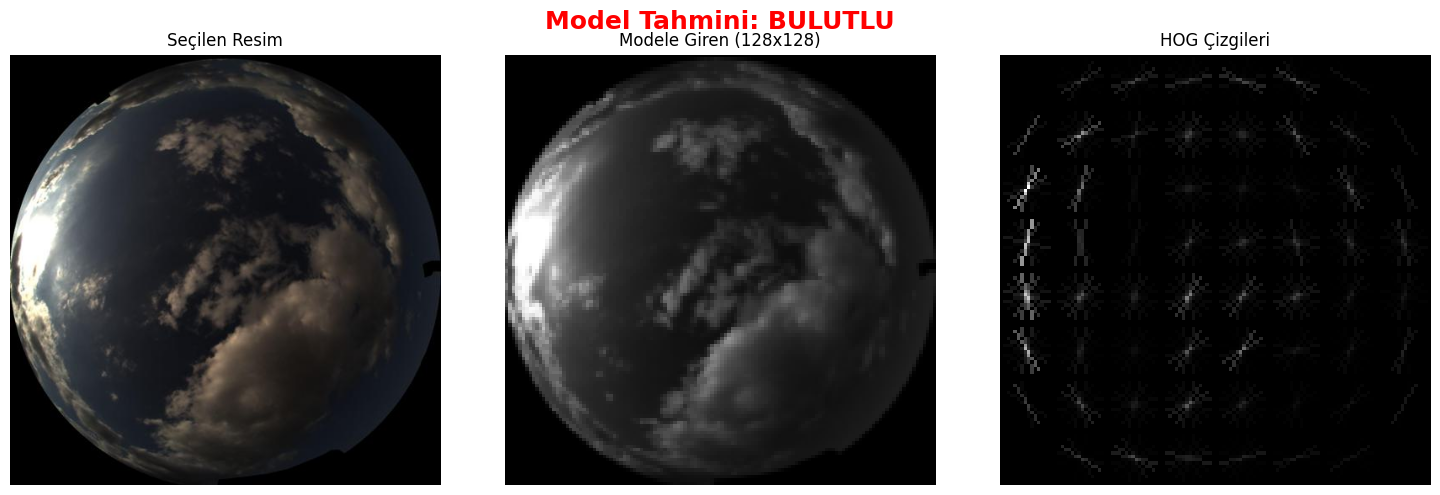

In [11]:
# 1. KENDİ SEÇTİĞİN RESMİN YOLUNU BURAYA YAZ
test_resmi_yolu = "../almeria_data/kontas_2017/images/asi_015_170328172730.jpg" 

# 2. Resmi oku, griye çevir ve 128x128 boyutlandır
img = np.array(Image.open(test_resmi_yolu).convert('RGB'))
gray = rgb2gray(img)
small = resize(gray, (128, 128), anti_aliasing=True)

# 3. HOG özelliklerini çıkar
fd, hog_img = hog(small, orientations=8, pixels_per_cell=(16, 16),
                  cells_per_block=(1, 1), visualize=True, channel_axis=None)

# 4. Modeli Eğit (Saliseler sürer) ve Test Et
test_vektoru = fd.reshape(1, -1)
test_modeli = lr_clf.classifier(X_train, y_train)
tahmin = lr_clf.predict(test_modeli, test_vektoru)[0]

# 5. Sonucu Belirle
sonuc = "AÇIK GÖKYÜZÜ" if tahmin == 1 else "BULUTLU"
renk = "green" if tahmin == 1 else "red"

# 6. Ekrana Çizdir
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Model Tahmini: {sonuc}", color=renk, fontsize=18, fontweight='bold')

axes[0].imshow(img)
axes[0].set_title(f"Seçilen Resim")
axes[0].axis('off')

axes[1].imshow(small, cmap='gray')
axes[1].set_title("Modele Giren (128x128)")
axes[1].axis('off')

axes[2].imshow(rescale_intensity(hog_img, in_range=(0, 10)), cmap='gray')
axes[2].set_title("HOG Çizgileri")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 10. Ozet Tablo

In [10]:
df_results = pd.DataFrame(results).T.round(4)
df_results.index.name = 'Model'
df_results.columns = ['Accuracy', 'F1 Score']

print('SONUC TABLOSU')
print('=' * 35)
print(df_results.to_string())
print('=' * 35)
print(f'Veri: Almeria Dataset (Fabel et al. 2022)')
print(f'Egitim: {len(X_train)} | Test: {len(X_test)} goruntu')
print(f'Ozellik: HOG (128x128 px, 8 yon, 16x16 hucre)')
print(f'\nEn iyi: {best} - Accuracy={results[best]["Accuracy"]:.4f}')

SONUC TABLOSU
       Accuracy  F1 Score
Model                    
SVM      0.8701    0.8695
KNN      0.8896    0.8894
LR       0.9091    0.9087
NB       0.7727    0.7776
Veri: Almeria Dataset (Fabel et al. 2022)
Egitim: 616 | Test: 154 goruntu
Ozellik: HOG (128x128 px, 8 yon, 16x16 hucre)

En iyi: LR - Accuracy=0.9091
